# Gradient descent
Using only matplotlib and numpy, creat a linear regression model using batch gradient descent.
Use this dataset:
| x    | y       |
|------|---------|
| 1.2  | 39344.0 |
| 1.4  | 46206.0 |
| 1.6  | 37732.0 |
| 2.1  | 43526.0 |
| 2.3  | 39892.0 |
| 3.0  | 56643.0 |
| 3.1  | 60151.0 |
| 3.3  | 54446.0 |
| 3.3  | 64446.0 |
| 3.8  | 57190.0 |
| 4.0  | 63219.0 |
| 4.1  | 55795.0 |
| 4.1  | 56958.0 |
| 4.2  | 57082.0 |
| 4.6  | 61112.0 |
| 5.0  | 67939.0 |
| 5.2  | 66030.0 |
| 5.4  | 83089.0 |
| 6.0  | 81364.0 |
| 6.1  | 93941.0 |
| 6.9  | 91739.0 |
| 7.2  | 98274.0 |
| 8.0  | 101303.0 |
| 8.3  | 113813.0 |
| 8.8  | 109432.0 |
| 9.1  | 105583.0 |
| 9.6  | 116970.0 |
| 9.7  | 112636.0 |
| 10.4 | 122392.0 |
| 10.6 | 121873.0 |

Import libraries

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import math

Import data set

In [12]:
x_train = np.array([
    1.2, 1.4, 1.6, 2.1, 2.3, 3.0, 3.1, 3.3, 3.3, 3.8,
    4.0, 4.1, 4.1, 4.2, 4.6, 5.0, 5.2, 5.4, 6.0, 6.1,
    6.9, 7.2, 8.0, 8.3, 8.8, 9.1, 9.6, 9.7, 10.4, 10.6
])

y_train = np.array([
    39344.0, 46206.0, 37732.0, 43526.0, 39892.0,
    56643.0, 60151.0, 54446.0, 64446.0, 57190.0,
    63219.0, 55795.0, 56958.0, 57082.0, 61112.0,
    67939.0, 66030.0, 83089.0, 81364.0, 93941.0,
    91739.0, 98274.0, 101303.0, 113813.0, 109432.0,
    105583.0, 116970.0, 112636.0, 122392.0, 121873.0
])

PLot training examples

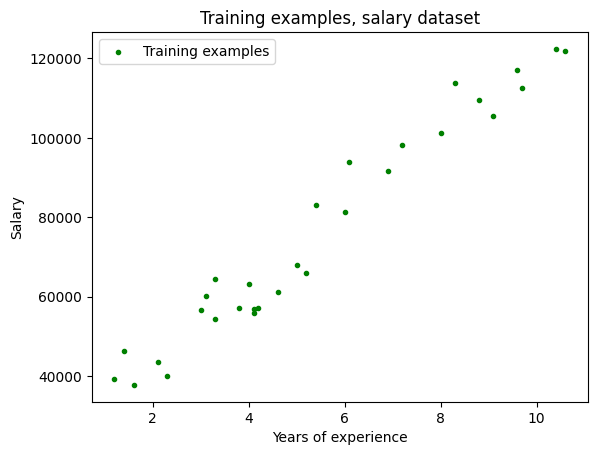

In [13]:
plt.scatter(x_train, y_train, color='g', marker='.', label='Training examples')
plt.xlabel("Years of experience")
plt.ylabel("Salary")
plt.title("Training examples, salary dataset")
plt.legend()
plt.show()

In [14]:
def compute_cost(x, y, b, w):
    m = x.shape[0]
    cost = 0
    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i]) ** 2
    return cost * (1/(2*m))

Run gradient iteration

In [15]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0
    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = (f_wb - y[i])
        dj_dw += dj_dw_i
        dj_db += dj_db_i

    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db

Run gradient descent.

In [30]:
def gradient_descent(num_iters, in_b, in_w, alpha):
    J_history = [] # Keeps history of cost values
    h_history = [] # Keeps history of w and b, the parameters
    b = in_b # Sets b to its initial b value
    w = in_w # Sets w to its initial w value

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)
        b -= alpha * dj_db
        w -= alpha * dj_dw

        if i < 100000: # Prevents resource exhaustion
            J_history.append(compute_cost(x_train, y_train, b, w))
            h_history.append([w, b])

        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:3}, Cost: {J_history[-1]:.3e}",
                  f"dj_dw: {dj_dw:.3e}, dj_db: {dj_db:.3e}",
                  f"w: {w:.3e}, b: {b:.3e}")

    return b, w, J_history

Set values and run gradient descent

In [ ]:
# Initialize parameters
initial_b = 0
initial_w = 0

# Set some gradient descent settings
learning_rate = 1.0e-2
num_iters = 10000

b, w, J_history = gradient_descent(num_iters, initial_b, initial_w, learning_rate)

Iteration   0, Cost: 1.298e+09 dj_dw: -4.850e+05, dj_db: -7.600e+04 w: 4.850e+03, b: 7.600e+02
Iteration 1000, Cost: 1.654e+07 dj_dw: 8.854e+01, dj_db: -6.033e+02 w: 9.880e+03, b: 2.192e+04
Iteration 2000, Cost: 1.565e+07 dj_dw: 1.132e+01, dj_db: -7.711e+01 w: 9.505e+03, b: 2.447e+04
Iteration 3000, Cost: 1.564e+07 dj_dw: 1.447e+00, dj_db: -9.856e+00 w: 9.457e+03, b: 2.480e+04
Iteration 4000, Cost: 1.564e+07 dj_dw: 1.849e-01, dj_db: -1.260e+00 w: 9.451e+03, b: 2.484e+04
Iteration 5000, Cost: 1.564e+07 dj_dw: 2.363e-02, dj_db: -1.610e-01 w: 9.450e+03, b: 2.485e+04
Iteration 6000, Cost: 1.564e+07 dj_dw: 3.021e-03, dj_db: -2.058e-02 w: 9.450e+03, b: 2.485e+04
Iteration 7000, Cost: 1.564e+07 dj_dw: 3.862e-04, dj_db: -2.631e-03 w: 9.450e+03, b: 2.485e+04
Iteration 8000, Cost: 1.564e+07 dj_dw: 4.936e-05, dj_db: -3.363e-04 w: 9.450e+03, b: 2.485e+04
Iteration 9000, Cost: 1.564e+07 dj_dw: 6.309e-06, dj_db: -4.299e-05 w: 9.450e+03, b: 2.485e+04


Plot cost function 

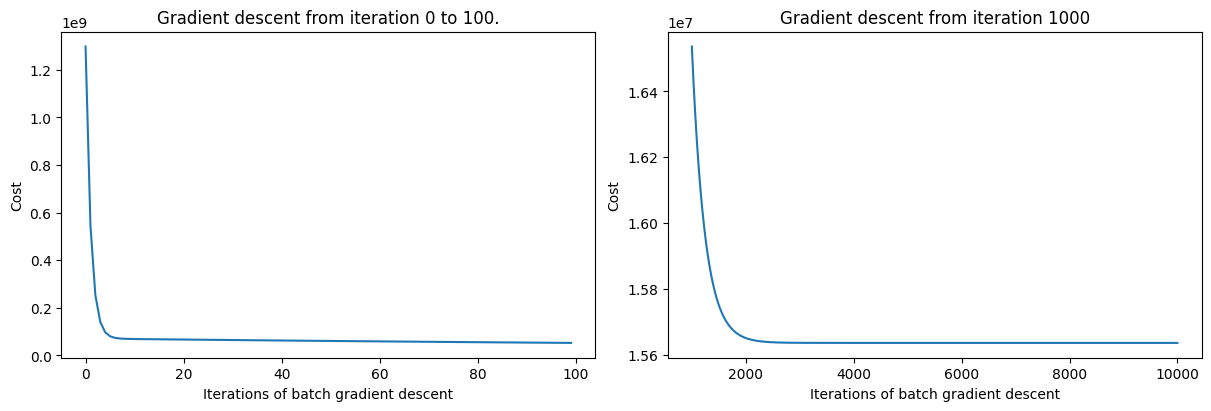

In [ ]:
# Create figure of 2 axis
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12,4))

# Plot cost function
ax1.plot(J_history[:100])
ax2.plot(1000 + np.arange(len(J_history[1000:])), J_history[1000:])

# Set labels and titles
ax1.set_xlabel("Iterations of batch gradient descent")
ax1.set_ylabel("Cost")
ax2.set_xlabel("Iterations of batch gradient descent")
ax2.set_ylabel("Cost")
ax1.set_title("Gradient descent from iteration 0 to 100.")
ax2.set_title("Gradient descent from iteration 1000")
plt.show()

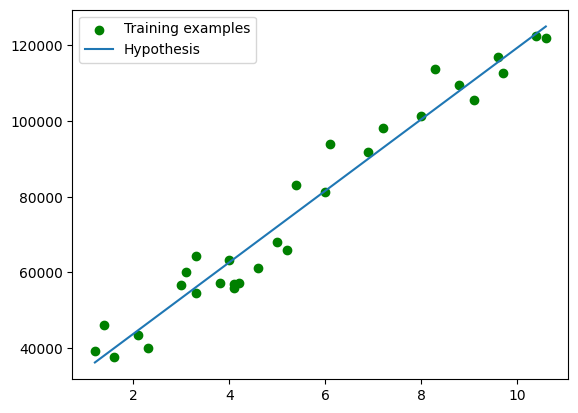

In [62]:
f_wb = w * x_train + b # Computes hypothesis, needed for plotting the hypothesis

plt.scatter(x_train, y_train, color="g", label="Training examples")
plt.plot(x_train, f_wb, label="Hypothesis")
plt.legend()
plt.show()

Predict salary

In [65]:
years_experience = float(input("Enter years of experience to predict salary"))
print(f"The predicted salary for someone with {years_experience} of experience is {w * years_experience + b:.2f}")

The predicted salary for someone with 20.0 of experience is 213847.45
